# Cumulative Heat Load and Recovery Dynamics: Temporal Stress Accumulation in Cattle

## Scientific Background

Livestock heat stress is not just about single extreme events, but about **cumulative exposure** and **inadequate recovery** over time. This analysis focuses on:

1. **Cumulative Heat Load**: Accumulated heat exposure over multi-week windows
2. **Recovery Periods**: Time between heat events for physiological recovery
3. **Heat Wave Characteristics**: Duration, intensity, and frequency of sustained heat
4. **Recovery Deficit**: Insufficient cooling between successive heat events
5. **Temporal Memory**: How past stress affects current mortality response

### Physiological Rationale

Cattle experiencing prolonged heat stress undergo:
- **Metabolic exhaustion**: Depleted energy reserves from thermoregulation
- **Reduced feed intake**: Lower energy availability
- **Immune suppression**: Increased disease susceptibility
- **Cardiovascular strain**: Chronic elevated heart rate
- **Reduced reproductive function**: Lower conception rates

Recovery requires:
- **Metabolic restoration**: 3-7 days for full recovery
- **Thermal equilibrium**: Cool nights for heat dissipation
- **Reduced respiratory stress**: Lower ambient temperature and humidity

### Research Questions

1. Does cumulative heat load (2-8 week windows) predict mortality better than single-week metrics?
2. What is the critical recovery period duration for preventing mortality?
3. Do heat waves (sustained multi-day events) have disproportionate impacts?
4. Is there evidence of temporal memory in mortality response?
5. How do acute vs chronic exposure patterns differ in their mortality effects?

### Hypotheses

**H1**: Cumulative heat load over 4-6 weeks correlates more strongly with mortality than single-week exposure  
**H2**: Recovery periods <14 days between heat events increase mortality risk  
**H3**: Heat waves (≥7 consecutive days) have exponential mortality effects  
**H4**: Summer heat has stronger carryover effects than spring heat  
**H5**: Chronic moderate stress causes higher mortality than rare acute extremes

---

In [20]:
# Import libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Import project configuration
import sys
sys.path.append('../../')
from config import (
    STATE_NAMES, STATE_ABBRS, STATE_REGIONS, 
    FOCUS_STATES, CATTLE_REGIONS, CUSTOM_REGIONS, SEASONS
)

# Set plotting style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully")
print(f"Focus states (n={len(FOCUS_STATES)}): {sorted([STATE_ABBRS[s] for s in FOCUS_STATES.values()])}")

Libraries loaded successfully
Focus states (n=14): ['AL', 'AR', 'AZ', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'NM', 'OK', 'SC', 'TN', 'TX']


## 1. Data Loading and Preparation

In [21]:
# Load and merge cattle-heat dataset
from config import PROCESSED_WEEKLY_DIR, MASK_FILE, CATTLE_DATA_FILE, CATTLE_REGION_IDS

print("Loading climate data...")
ds_night = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_nighttime_recovery.nc')
ds_day = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_daytime_heat.nc')
ds_vpd = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_vpd.nc')

# Get week dates from climate data
week_dates = ds_night['week'].values
n_weeks = len(week_dates)

print(f"Climate data: {n_weeks} weeks")
print(f"  From: {pd.to_datetime(week_dates[0]).date()}")
print(f"  To: {pd.to_datetime(week_dates[-1]).date()}")

# Load state mask for regional aggregation
ds_mask = xr.open_dataset(MASK_FILE)
state_mask = ds_mask.state_mask.load()
ds_mask.close()

# Helper function to compute regional mean
def compute_regional_mean(data, state_ids, state_mask):
    """Compute spatial mean across multiple states."""
    combined_mask = xr.zeros_like(state_mask, dtype=bool)
    for state_id in state_ids:
        combined_mask = combined_mask | (state_mask == state_id)
    masked_data = data.where(combined_mask)
    return masked_data.mean(dim=['lat', 'lon']).astype(np.float64)

# Define region IDs
region_4_ids = CATTLE_REGION_IDS['region_4']
region_6_ids = CATTLE_REGION_IDS['region_6']

# Compute regional climate metrics for Region 4
print("\nComputing regional climate metrics...")
r4_metrics = pd.DataFrame({
    'week_ending': pd.to_datetime(week_dates),
    'region': 4,
    'mean_daytime_hours_above_30': compute_regional_mean(ds_day['hours_above_30'], region_4_ids, state_mask).values,
    'mean_daytime_hours_above_35': compute_regional_mean(ds_day['hours_above_35'], region_4_ids, state_mask).values,
    'mean_nighttime_hours_above_21': compute_regional_mean(ds_night['hours_above_21'], region_4_ids, state_mask).values,
    'mean_vpd_mean': compute_regional_mean(ds_vpd['vpd_mean'], region_4_ids, state_mask).values,
})

# Compute regional climate metrics for Region 6
r6_metrics = pd.DataFrame({
    'week_ending': pd.to_datetime(week_dates),
    'region': 6,
    'mean_daytime_hours_above_30': compute_regional_mean(ds_day['hours_above_30'], region_6_ids, state_mask).values,
    'mean_daytime_hours_above_35': compute_regional_mean(ds_day['hours_above_35'], region_6_ids, state_mask).values,
    'mean_nighttime_hours_above_21': compute_regional_mean(ds_night['hours_above_21'], region_6_ids, state_mask).values,
    'mean_vpd_mean': compute_regional_mean(ds_vpd['vpd_mean'], region_6_ids, state_mask).values,
})

# Combine regions
climate_data = pd.concat([r4_metrics, r6_metrics], ignore_index=True)

# Load cattle data
print("Loading cattle data...")
cattle_data = pd.read_csv(CATTLE_DATA_FILE, parse_dates=['date'])
cattle_data = cattle_data.rename(columns={'date': 'week_ending'})

# Reshape cattle data for regions 4 and 6
cattle_r4 = cattle_data[['week_ending', 'region_4_beef_dairy']].copy()
cattle_r4['region'] = 4
cattle_r4['total_beef_dairy'] = cattle_r4['region_4_beef_dairy']
cattle_r4 = cattle_r4.drop(columns=['region_4_beef_dairy'])

cattle_r6 = cattle_data[['week_ending', 'region_6_beef_dairy']].copy()
cattle_r6['region'] = 6
cattle_r6['total_beef_dairy'] = cattle_r6['region_6_beef_dairy']
cattle_r6 = cattle_r6.drop(columns=['region_6_beef_dairy'])

cattle_regional = pd.concat([cattle_r4, cattle_r6], ignore_index=True)

# Merge cattle and climate data
print("Merging datasets...")
cattle_heat = pd.merge(cattle_regional, climate_data, on=['week_ending', 'region'], how='inner')

print(f"\nMerged dataset: {len(cattle_heat)} region-weeks")
print(f"Date range: {cattle_heat['week_ending'].min()} to {cattle_heat['week_ending'].max()}")

# Add temporal features
cattle_heat['year'] = cattle_heat['week_ending'].dt.year
cattle_heat['month'] = cattle_heat['week_ending'].dt.month
cattle_heat['week_of_year'] = cattle_heat['week_ending'].dt.isocalendar().week

def get_season(month):
    if month in SEASONS['Winter']:
        return 'Winter'
    elif month in SEASONS['Spring']:
        return 'Spring'
    elif month in SEASONS['Summer']:
        return 'Summer'
    else:
        return 'Fall'

cattle_heat['season'] = cattle_heat['month'].apply(get_season)
cattle_heat['decade'] = (cattle_heat['year'] // 10) * 10

# Focus on Regions 4 and 6
cattle_focus = cattle_heat[cattle_heat['region'].isin([4, 6])].copy()
cattle_focus = cattle_focus.sort_values(['region', 'week_ending']).reset_index(drop=True)

print(f"\nFocused on Regions 4 & 6: {len(cattle_focus)} region-weeks")
print(f"Date range: {cattle_focus['year'].min()}-{cattle_focus['year'].max()}")
cattle_focus.head()

Loading climate data...
Climate data: 2191 weeks
  From: 1984-01-07
  To: 2025-12-27

Computing regional climate metrics...
Loading cattle data...
Merging datasets...

Merged dataset: 4382 region-weeks
Date range: 1984-01-07 00:00:00 to 2025-12-27 00:00:00

Focused on Regions 4 & 6: 4382 region-weeks
Date range: 1984-2025


,week_ending,region,total_beef_dairy,mean_daytime_hours_above_30,mean_daytime_hours_above_35,mean_nighttime_hours_above_21,mean_vpd_mean,year,month,week_of_year,season,decade
0,1984-01-07,4,21.3,0.0,0.0,0.000000e+00,0.210009,1984,1,1,Winter,1980
1,1984-01-14,4,19.1,0.0,0.0,9.201278e+11,0.164918,1984,1,2,Winter,1980
2,1984-01-21,4,17.9,0.0,0.0,4.129073e+12,0.139563,1984,1,3,Winter,1980
3,1984-01-28,4,18.2,0.0,0.0,6.130351e+12,0.164621,1984,1,4,Winter,1980
4,1984-02-04,4,17.2,0.0,0.0,1.253674e+12,0.268931,1984,2,5,Winter,1980


## 2. Calculate Cumulative Heat Load

Compute rolling sums of heat exposure over multiple time windows (2, 4, 6, and 8 weeks).

In [22]:
# Define heat metrics to accumulate
heat_metrics = [
    'mean_daytime_hours_above_30',
    'mean_daytime_hours_above_35',
    'mean_nighttime_hours_above_21',
    'mean_vpd_mean'
]

# Calculate rolling sums for different window sizes
window_sizes = [2, 4, 6, 8]  # weeks

for window in window_sizes:
    for metric in heat_metrics:
        col_name = f'{metric}_cumulative_{window}wk'
        
        # Calculate rolling sum within each region
        cattle_focus[col_name] = cattle_focus.groupby('region')[metric].transform(
            lambda x: x.rolling(window=window, min_periods=1).sum()
        )

print(f"Cumulative metrics calculated for window sizes: {window_sizes} weeks")
print(f"Total new columns: {len(window_sizes) * len(heat_metrics)}")

# Show example
example_cols = ['week_ending', 'region', 'mean_daytime_hours_above_30',
                'mean_daytime_hours_above_30_cumulative_4wk',
                'mean_daytime_hours_above_30_cumulative_8wk']
print("\nExample cumulative calculations:")
print(cattle_focus[example_cols].head(10))

Cumulative metrics calculated for window sizes: [2, 4, 6, 8] weeks
Total new columns: 16

Example cumulative calculations:
  week_ending  region  mean_daytime_hours_above_30  \
0  1984-01-07       4                          0.0   
1  1984-01-14       4                          0.0   
2  1984-01-21       4                          0.0   
3  1984-01-28       4                          0.0   
4  1984-02-04       4                          0.0   
5  1984-02-11       4                          0.0   
6  1984-02-18       4                          0.0   
7  1984-02-25       4                          0.0   
8  1984-03-03       4                          0.0   
9  1984-03-10       4                          0.0   

   mean_daytime_hours_above_30_cumulative_4wk  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                    

## 3. Correlation Analysis: Single Week vs Cumulative

Compare how well single-week metrics vs cumulative metrics correlate with mortality.

In [23]:
mortality_var = 'total_beef_dairy'

# Calculate correlations for different window sizes
correlation_results = []

for metric in heat_metrics:
    # Single week (baseline)
    valid_data = cattle_focus[[metric, mortality_var]].dropna()
    if len(valid_data) > 10:
        corr, pval = pearsonr(valid_data[metric], valid_data[mortality_var])
        correlation_results.append({
            'Metric': metric,
            'Window': '1 week',
            'Correlation': corr,
            'P-value': pval
        })
    
    # Cumulative windows
    for window in window_sizes:
        cum_col = f'{metric}_cumulative_{window}wk'
        valid_data = cattle_focus[[cum_col, mortality_var]].dropna()
        if len(valid_data) > 10:
            corr, pval = pearsonr(valid_data[cum_col], valid_data[mortality_var])
            correlation_results.append({
                'Metric': metric,
                'Window': f'{window} weeks',
                'Correlation': corr,
                'P-value': pval
            })

corr_df = pd.DataFrame(correlation_results)

print("="*80)
print("CORRELATION ANALYSIS: Single Week vs Cumulative Heat Load")
print("="*80)
print(corr_df.to_string(index=False))

# Find optimal window for each metric
print("\n" + "="*80)
print("OPTIMAL WINDOW SIZE BY METRIC")
print("="*80)
for metric in heat_metrics:
    metric_corrs = corr_df[corr_df['Metric'] == metric]
    best_window = metric_corrs.loc[metric_corrs['Correlation'].abs().idxmax()]
    print(f"\n{metric}:")
    print(f"  Best window: {best_window['Window']}")
    print(f"  Correlation: {best_window['Correlation']:.4f}")
    print(f"  P-value: {best_window['P-value']:.4e}")

CORRELATION ANALYSIS: Single Week vs Cumulative Heat Load
                       Metric  Window  Correlation      P-value
  mean_daytime_hours_above_30  1 week     0.044351 3.319580e-03
  mean_daytime_hours_above_30 2 weeks     0.051683 6.203784e-04
  mean_daytime_hours_above_30 4 weeks     0.069541 4.071964e-06
  mean_daytime_hours_above_30 6 weeks     0.089490 2.954085e-09
  mean_daytime_hours_above_30 8 weeks     0.110661 2.044242e-13
  mean_daytime_hours_above_35  1 week     0.145483 3.692361e-22
  mean_daytime_hours_above_35 2 weeks     0.157850 7.593335e-26
  mean_daytime_hours_above_35 4 weeks     0.182248 4.906085e-34
  mean_daytime_hours_above_35 6 weeks     0.203334 4.088962e-42
  mean_daytime_hours_above_35 8 weeks     0.227344 1.772347e-52
mean_nighttime_hours_above_21  1 week     0.057536 1.385287e-04
mean_nighttime_hours_above_21 2 weeks     0.065870 1.277863e-05
mean_nighttime_hours_above_21 4 weeks     0.085396 1.499117e-08
mean_nighttime_hours_above_21 6 weeks     0.10

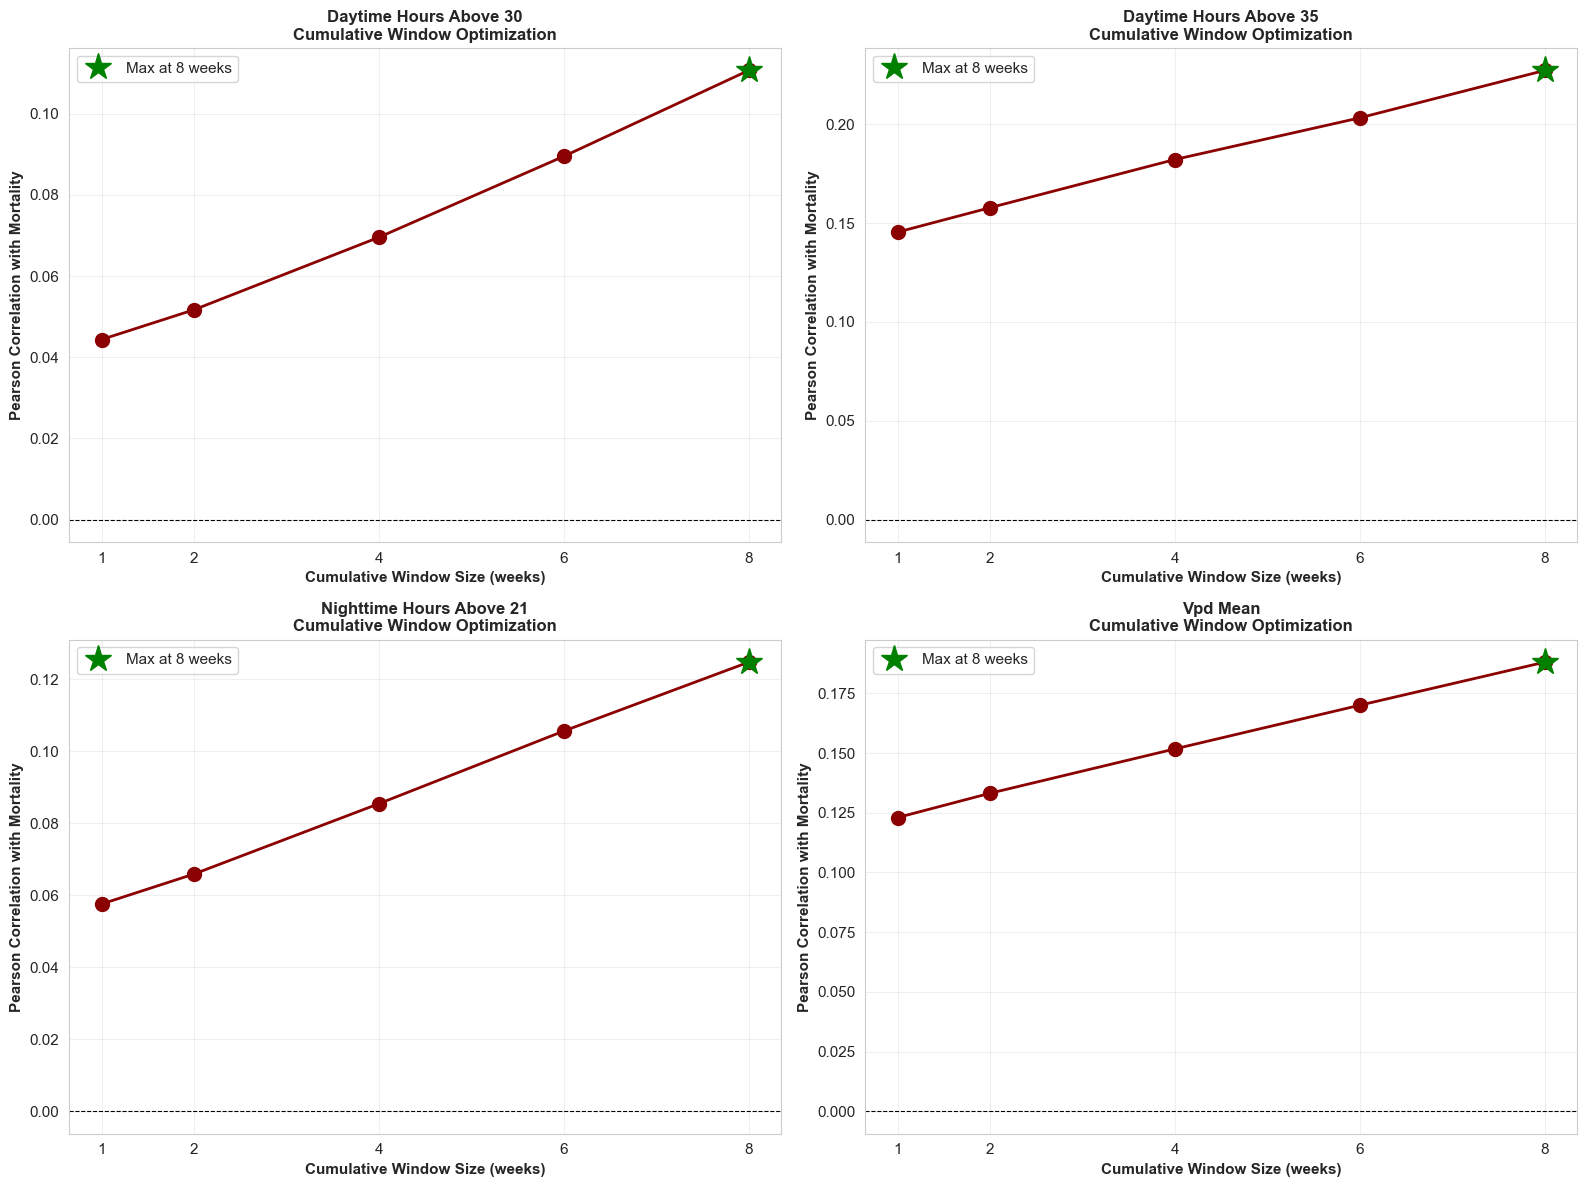

Figure saved: 01_cumulative_window_optimization.png


In [24]:
# Visualize correlation by window size
import os
os.makedirs('../../figures/cumulative_heat_recovery', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(heat_metrics):
    ax = axes[idx]
    
    metric_data = corr_df[corr_df['Metric'] == metric]
    
    # Extract window sizes as numeric values
    window_values = []
    correlations = []
    for _, row in metric_data.iterrows():
        if 'week' in row['Window']:
            wk = int(row['Window'].split()[0])
            window_values.append(wk)
            correlations.append(row['Correlation'])
    
    # Plot
    ax.plot(window_values, correlations, 'o-', linewidth=2, markersize=10, color='darkred')
    
    # Mark maximum
    max_idx = np.argmax(np.abs(correlations))
    ax.plot(window_values[max_idx], correlations[max_idx], 'g*', markersize=20, 
            label=f'Max at {window_values[max_idx]} weeks')
    
    ax.set_xlabel('Cumulative Window Size (weeks)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pearson Correlation with Mortality', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.replace("mean_", "").replace("_", " ").title()}\nCumulative Window Optimization', 
                 fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(window_values)

plt.tight_layout()
plt.savefig('../../figures/cumulative_heat_recovery/01_cumulative_window_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 01_cumulative_window_optimization.png")

## 4. Heat Wave Detection and Characterization

Identify sustained heat events and analyze their characteristics.

In [25]:
# Define heat wave thresholds (weekly aggregated data)
HEAT_THRESHOLD = 20  # hours per week above 30°C
MIN_DURATION = 3     # consecutive weeks

def detect_heat_waves(data, threshold=HEAT_THRESHOLD, min_duration=MIN_DURATION):
    """
    Detect heat waves as consecutive weeks exceeding threshold.
    
    Returns:
    - heat_wave_id: unique ID for each heat wave (0 = no heat wave)
    - in_heat_wave: binary indicator
    """
    # Identify weeks exceeding threshold
    exceeds_threshold = data['mean_daytime_hours_above_30'] > threshold
    
    # Find consecutive runs
    heat_wave_id = 0
    heat_wave_ids = []
    current_run_length = 0
    
    for exceeds in exceeds_threshold:
        if exceeds:
            current_run_length += 1
            if current_run_length >= min_duration:
                heat_wave_ids.append(heat_wave_id)
            else:
                heat_wave_ids.append(0)  # Not yet a heat wave
        else:
            if current_run_length >= min_duration:
                heat_wave_id += 1  # Increment for next heat wave
            current_run_length = 0
            heat_wave_ids.append(0)
    
    # Post-process to assign same ID to entire heat wave
    processed_ids = []
    temp_run = []
    
    for i, exceeds in enumerate(exceeds_threshold):
        if exceeds:
            temp_run.append(i)
        else:
            if len(temp_run) >= min_duration:
                # Assign unique ID to this heat wave
                for j in temp_run:
                    processed_ids.append(heat_wave_id)
                heat_wave_id += 1
            else:
                # Too short, not a heat wave
                for j in temp_run:
                    processed_ids.append(0)
            temp_run = []
            processed_ids.append(0)
    
    # Handle final run
    if len(temp_run) >= min_duration:
        for j in temp_run:
            processed_ids.append(heat_wave_id)
    else:
        for j in temp_run:
            processed_ids.append(0)
    
    return processed_ids

# Apply heat wave detection separately for each region
cattle_focus['heat_wave_id'] = 0

for region in [4, 6]:
    region_mask = cattle_focus['region'] == region
    region_data = cattle_focus[region_mask].copy()
    
    hw_ids = detect_heat_waves(region_data)
    cattle_focus.loc[region_mask, 'heat_wave_id'] = hw_ids

cattle_focus['in_heat_wave'] = (cattle_focus['heat_wave_id'] > 0).astype(int)

print(f"Heat wave detection complete")
print(f"Total heat wave weeks: {cattle_focus['in_heat_wave'].sum()}")
print(f"Non-heat wave weeks: {(cattle_focus['in_heat_wave'] == 0).sum()}")
print(f"\nHeat wave distribution by region:")
print(cattle_focus.groupby('region')['in_heat_wave'].value_counts().unstack(fill_value=0))

Heat wave detection complete
Total heat wave weeks: 3121
Non-heat wave weeks: 1261

Heat wave distribution by region:
in_heat_wave    0     1
region                 
4             770  1421
6             491  1700


In [26]:
# Characterize heat waves
heat_wave_characteristics = []

for region in [4, 6]:
    region_data = cattle_focus[cattle_focus['region'] == region]
    
    for hw_id in region_data['heat_wave_id'].unique():
        if hw_id == 0:
            continue  # Skip non-heat wave periods
        
        hw_data = region_data[region_data['heat_wave_id'] == hw_id]
        
        heat_wave_characteristics.append({
            'region': region,
            'heat_wave_id': hw_id,
            'start_week': hw_data['week_ending'].min(),
            'end_week': hw_data['week_ending'].max(),
            'duration_weeks': len(hw_data),
            'mean_heat_hours': hw_data['mean_daytime_hours_above_30'].mean(),
            'max_heat_hours': hw_data['mean_daytime_hours_above_30'].max(),
            'total_heat_hours': hw_data['mean_daytime_hours_above_30'].sum(),
            'mean_vpd': hw_data['mean_vpd_mean'].mean(),
            'mean_mortality': hw_data[mortality_var].mean(),
            'total_mortality': hw_data[mortality_var].sum(),
            'season': hw_data['season'].mode()[0] if len(hw_data['season'].mode()) > 0 else 'Unknown'
        })

hw_df = pd.DataFrame(heat_wave_characteristics)

if len(hw_df) > 0:
    print("\nHeat Wave Characteristics:")
    print(f"Total heat waves detected: {len(hw_df)}")
    print(f"\nDuration statistics (weeks):")
    print(hw_df['duration_weeks'].describe())
    print(f"\nIntensity statistics (mean hours >30°C):")
    print(hw_df['mean_heat_hours'].describe())
    print(f"\nSeasonal distribution:")
    print(hw_df['season'].value_counts())
else:
    print("\nNo heat waves detected with current threshold")
    print("Consider lowering threshold or minimum duration")


Heat Wave Characteristics:
Total heat waves detected: 110

Duration statistics (weeks):
count    110.000000
mean      28.372727
std       14.450713
min        3.000000
25%       25.000000
50%       34.500000
75%       39.000000
max       45.000000
Name: duration_weeks, dtype: float64

Intensity statistics (mean hours >30°C):
count    1.100000e+02
mean     3.221472e+13
std      1.991309e+13
min      2.059497e+10
25%      2.367325e+13
50%      3.774689e+13
75%      4.614283e+13
max      6.690479e+13
Name: mean_heat_hours, dtype: float64

Seasonal distribution:
season
Summer    44
Spring    31
Winter    18
Fall      17
Name: count, dtype: int64


In [27]:
# Compare mortality during heat waves vs normal periods
print("\n" + "="*80)
print("MORTALITY COMPARISON: Heat Wave vs Normal Periods")
print("="*80)

hw_mortality = cattle_focus[cattle_focus['in_heat_wave'] == 1][mortality_var].dropna()
normal_mortality = cattle_focus[cattle_focus['in_heat_wave'] == 0][mortality_var].dropna()

print(f"\nHeat Wave Periods:")
print(f"  Mean mortality: {hw_mortality.mean():.1f} ± {hw_mortality.std():.1f}")
print(f"  Median mortality: {hw_mortality.median():.1f}")
print(f"  N weeks: {len(hw_mortality)}")

print(f"\nNormal Periods:")
print(f"  Mean mortality: {normal_mortality.mean():.1f} ± {normal_mortality.std():.1f}")
print(f"  Median mortality: {normal_mortality.median():.1f}")
print(f"  N weeks: {len(normal_mortality)}")

if len(hw_mortality) > 0 and len(normal_mortality) > 0:
    # Statistical test
    from scipy.stats import mannwhitneyu
    u_stat, p_value = mannwhitneyu(hw_mortality, normal_mortality, alternative='two-sided')
    
    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:.1f}")
    print(f"  P-value: {p_value:.4e}")
    print(f"  Conclusion: Mortality is {'significantly' if p_value < 0.05 else 'not significantly'} different")
    
    # Effect size
    fold_increase = hw_mortality.mean() / normal_mortality.mean()
    print(f"\nEffect Size:")
    print(f"  Fold increase during heat waves: {fold_increase:.2f}x")
    print(f"  Absolute difference: {hw_mortality.mean() - normal_mortality.mean():.1f} (1000 head per week)")


MORTALITY COMPARISON: Heat Wave vs Normal Periods

Heat Wave Periods:
  Mean mortality: 16.6 ± 5.2
  Median mortality: 15.3
  N weeks: 3121

Normal Periods:
  Mean mortality: 15.4 ± 4.6
  Median mortality: 14.6
  N weeks: 1261

Mann-Whitney U Test:
  U-statistic: 2205392.0
  P-value: 3.6806e-10
  Conclusion: Mortality is significantly different

Effect Size:
  Fold increase during heat waves: 1.08x
  Absolute difference: 1.2 (1000 head per week)


## 5. Recovery Period Analysis

Analyze time between heat events and its effect on mortality.

In [28]:
# Calculate weeks since last heat event
def calculate_recovery_time(data, threshold=HEAT_THRESHOLD):
    """
    Calculate weeks since last heat event for each observation.
    """
    exceeds_threshold = data['mean_daytime_hours_above_30'] > threshold
    weeks_since_heat = []
    counter = 0
    
    for exceeds in exceeds_threshold:
        if exceeds:
            weeks_since_heat.append(0)  # Currently in heat event
            counter = 0
        else:
            counter += 1
            weeks_since_heat.append(counter)
    
    return weeks_since_heat

# Apply separately for each region
cattle_focus['weeks_since_heat'] = 0

for region in [4, 6]:
    region_mask = cattle_focus['region'] == region
    region_data = cattle_focus[region_mask].copy()
    
    recovery_times = calculate_recovery_time(region_data)
    cattle_focus.loc[region_mask, 'weeks_since_heat'] = recovery_times

print("Recovery time calculated")
print(f"\nRecovery time distribution (weeks):")
print(cattle_focus['weeks_since_heat'].describe())

Recovery time calculated

Recovery time distribution (weeks):
count    4382.000000
mean        1.572113
std         3.813224
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        26.000000
Name: weeks_since_heat, dtype: float64


In [29]:
# Categorize recovery periods
def categorize_recovery(weeks):
    if weeks == 0:
        return 'In heat event'
    elif weeks <= 2:
        return 'Short recovery (1-2 wk)'
    elif weeks <= 4:
        return 'Moderate recovery (3-4 wk)'
    elif weeks <= 8:
        return 'Long recovery (5-8 wk)'
    else:
        return 'Extended recovery (>8 wk)'

cattle_focus['recovery_category'] = cattle_focus['weeks_since_heat'].apply(categorize_recovery)

# Analyze mortality by recovery category
recovery_mortality = cattle_focus.groupby('recovery_category')[mortality_var].agg([
    'mean', 'median', 'std', 'count'
])

print("\nMortality by Recovery Period:")
print(recovery_mortality)


Mortality by Recovery Period:
                                 mean  median       std  count
recovery_category                                             
Extended recovery (>8 wk)   14.095625   13.45  3.274607    320
In heat event               16.566660   15.30  5.145078   3275
Long recovery (5-8 wk)      14.673750   13.95  4.782727    232
Moderate recovery (3-4 wk)  15.547191   14.70  4.956525    178
Short recovery (1-2 wk)     16.197878   15.40  5.049041    377


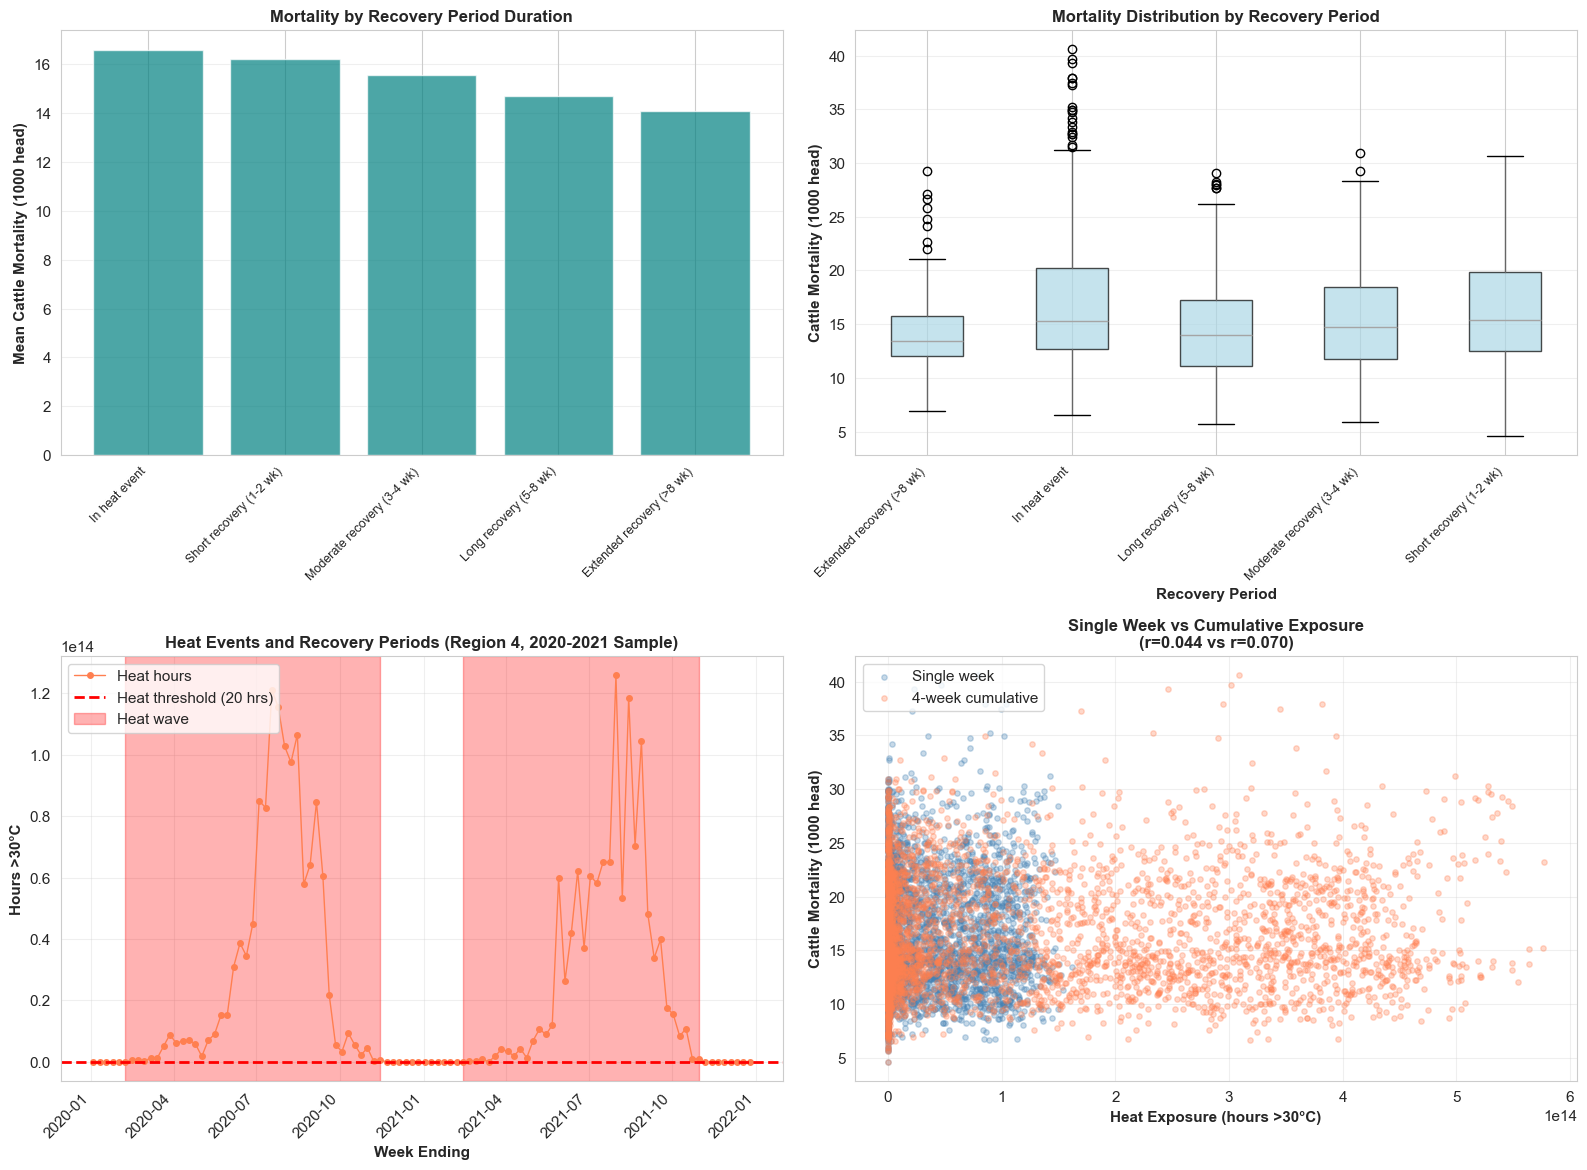

Figure saved: 02_recovery_period_analysis.png


In [30]:
# Visualize recovery effects
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mortality vs weeks since heat (binned)
ax = axes[0, 0]
recovery_cats = ['In heat event', 'Short recovery (1-2 wk)', 'Moderate recovery (3-4 wk)', 
                  'Long recovery (5-8 wk)', 'Extended recovery (>8 wk)']
mortality_by_recovery = []
for cat in recovery_cats:
    cat_data = cattle_focus[cattle_focus['recovery_category'] == cat][mortality_var].dropna()
    if len(cat_data) > 0:
        mortality_by_recovery.append(cat_data.mean())
    else:
        mortality_by_recovery.append(np.nan)

ax.bar(range(len(recovery_cats)), mortality_by_recovery, color='teal', alpha=0.7)
ax.set_xticks(range(len(recovery_cats)))
ax.set_xticklabels(recovery_cats, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_title('Mortality by Recovery Period Duration', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Box plot
ax = axes[0, 1]
cattle_focus.boxplot(column=mortality_var, by='recovery_category', ax=ax, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_xlabel('Recovery Period', fontsize=11, fontweight='bold')
ax.set_ylabel('Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_title('Mortality Distribution by Recovery Period', fontsize=12, fontweight='bold')
plt.suptitle('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Time series showing recovery periods
ax = axes[1, 0]
sample_data = cattle_focus[(cattle_focus['region'] == 4) & 
                           (cattle_focus['year'].isin([2020, 2021]))].copy()
if len(sample_data) > 0:
    ax.plot(sample_data['week_ending'], sample_data['mean_daytime_hours_above_30'], 
            'o-', linewidth=1, markersize=4, label='Heat hours', color='coral')
    ax.axhline(HEAT_THRESHOLD, color='red', linewidth=2, linestyle='--', label=f'Heat threshold ({HEAT_THRESHOLD} hrs)')
    
    # Shade heat wave periods
    for hw_id in sample_data['heat_wave_id'].unique():
        if hw_id > 0:
            hw_weeks = sample_data[sample_data['heat_wave_id'] == hw_id]
            ax.axvspan(hw_weeks['week_ending'].min(), hw_weeks['week_ending'].max(), 
                      alpha=0.3, color='red', label='Heat wave' if hw_id == sample_data[sample_data['heat_wave_id'] > 0]['heat_wave_id'].min() else '')
    
    ax.set_xlabel('Week Ending', fontsize=11, fontweight='bold')
    ax.set_ylabel('Hours >30°C', fontsize=11, fontweight='bold')
    ax.set_title('Heat Events and Recovery Periods (Region 4, 2020-2021 Sample)', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
else:
    ax.text(0.5, 0.5, 'No data for 2020-2021', ha='center', va='center', transform=ax.transAxes)

# Plot 4: Cumulative vs single week comparison
ax = axes[1, 1]
# Compare mortality correlation: single week vs 4-week cumulative
single_week_data = cattle_focus[['mean_daytime_hours_above_30', mortality_var]].dropna()
cumulative_data = cattle_focus[['mean_daytime_hours_above_30_cumulative_4wk', mortality_var]].dropna()

if len(single_week_data) > 0:
    ax.scatter(single_week_data['mean_daytime_hours_above_30'], single_week_data[mortality_var],
              alpha=0.3, s=15, color='steelblue', label='Single week')
    corr_single, _ = pearsonr(single_week_data['mean_daytime_hours_above_30'], single_week_data[mortality_var])

if len(cumulative_data) > 0:
    ax.scatter(cumulative_data['mean_daytime_hours_above_30_cumulative_4wk'], cumulative_data[mortality_var],
              alpha=0.3, s=15, color='coral', label='4-week cumulative')
    corr_cum, _ = pearsonr(cumulative_data['mean_daytime_hours_above_30_cumulative_4wk'], cumulative_data[mortality_var])

ax.set_xlabel('Heat Exposure (hours >30°C)', fontsize=11, fontweight='bold')
ax.set_ylabel('Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_title(f'Single Week vs Cumulative Exposure\n(r={corr_single:.3f} vs r={corr_cum:.3f})', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../figures/cumulative_heat_recovery/02_recovery_period_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 02_recovery_period_analysis.png")

## 6. Temporal Lag Analysis

Examine how heat exposure in previous weeks affects current mortality (temporal memory).

In [31]:
# Create lagged heat variables
max_lag = 8  # weeks

for lag in range(1, max_lag + 1):
    for metric in heat_metrics:
        lag_col = f'{metric}_lag{lag}'
        
        # Create lag within each region
        cattle_focus[lag_col] = cattle_focus.groupby('region')[metric].shift(lag)

print(f"Created lagged variables for lags 1-{max_lag} weeks")
print(f"Total new columns: {max_lag * len(heat_metrics)}")

Created lagged variables for lags 1-8 weeks
Total new columns: 32


In [32]:
# Calculate correlations at different lags
lag_correlations = []

for metric in heat_metrics:
    # Current week (lag 0)
    valid_data = cattle_focus[[metric, mortality_var]].dropna()
    if len(valid_data) > 10:
        corr, pval = pearsonr(valid_data[metric], valid_data[mortality_var])
        lag_correlations.append({
            'Metric': metric,
            'Lag': 0,
            'Correlation': corr,
            'P-value': pval
        })
    
    # Lagged weeks
    for lag in range(1, max_lag + 1):
        lag_col = f'{metric}_lag{lag}'
        valid_data = cattle_focus[[lag_col, mortality_var]].dropna()
        if len(valid_data) > 10:
            corr, pval = pearsonr(valid_data[lag_col], valid_data[mortality_var])
            lag_correlations.append({
                'Metric': metric,
                'Lag': lag,
                'Correlation': corr,
                'P-value': pval
            })

lag_corr_df = pd.DataFrame(lag_correlations)

print("="*80)
print("TEMPORAL LAG ANALYSIS: Heat Exposure vs Mortality")
print("="*80)
print(lag_corr_df.head(20).to_string(index=False))

TEMPORAL LAG ANALYSIS: Heat Exposure vs Mortality
                       Metric  Lag  Correlation      P-value
  mean_daytime_hours_above_30    0     0.044351 3.319580e-03
  mean_daytime_hours_above_30    1     0.057365 1.455414e-04
  mean_daytime_hours_above_30    2     0.072956 1.349605e-06
  mean_daytime_hours_above_30    3     0.092780 7.794821e-10
  mean_daytime_hours_above_30    4     0.109199 4.434493e-13
  mean_daytime_hours_above_30    5     0.127249 3.019168e-17
  mean_daytime_hours_above_30    6     0.144669 7.162579e-22
  mean_daytime_hours_above_30    7     0.158256 6.791026e-26
  mean_daytime_hours_above_30    8     0.174564 3.243694e-31
  mean_daytime_hours_above_35    0     0.145483 3.692361e-22
  mean_daytime_hours_above_35    1     0.154349 9.253140e-25
  mean_daytime_hours_above_35    2     0.170024 9.397555e-30
  mean_daytime_hours_above_35    3     0.181913 7.172768e-34
  mean_daytime_hours_above_35    4     0.187346 7.694798e-36
  mean_daytime_hours_above_35    5 

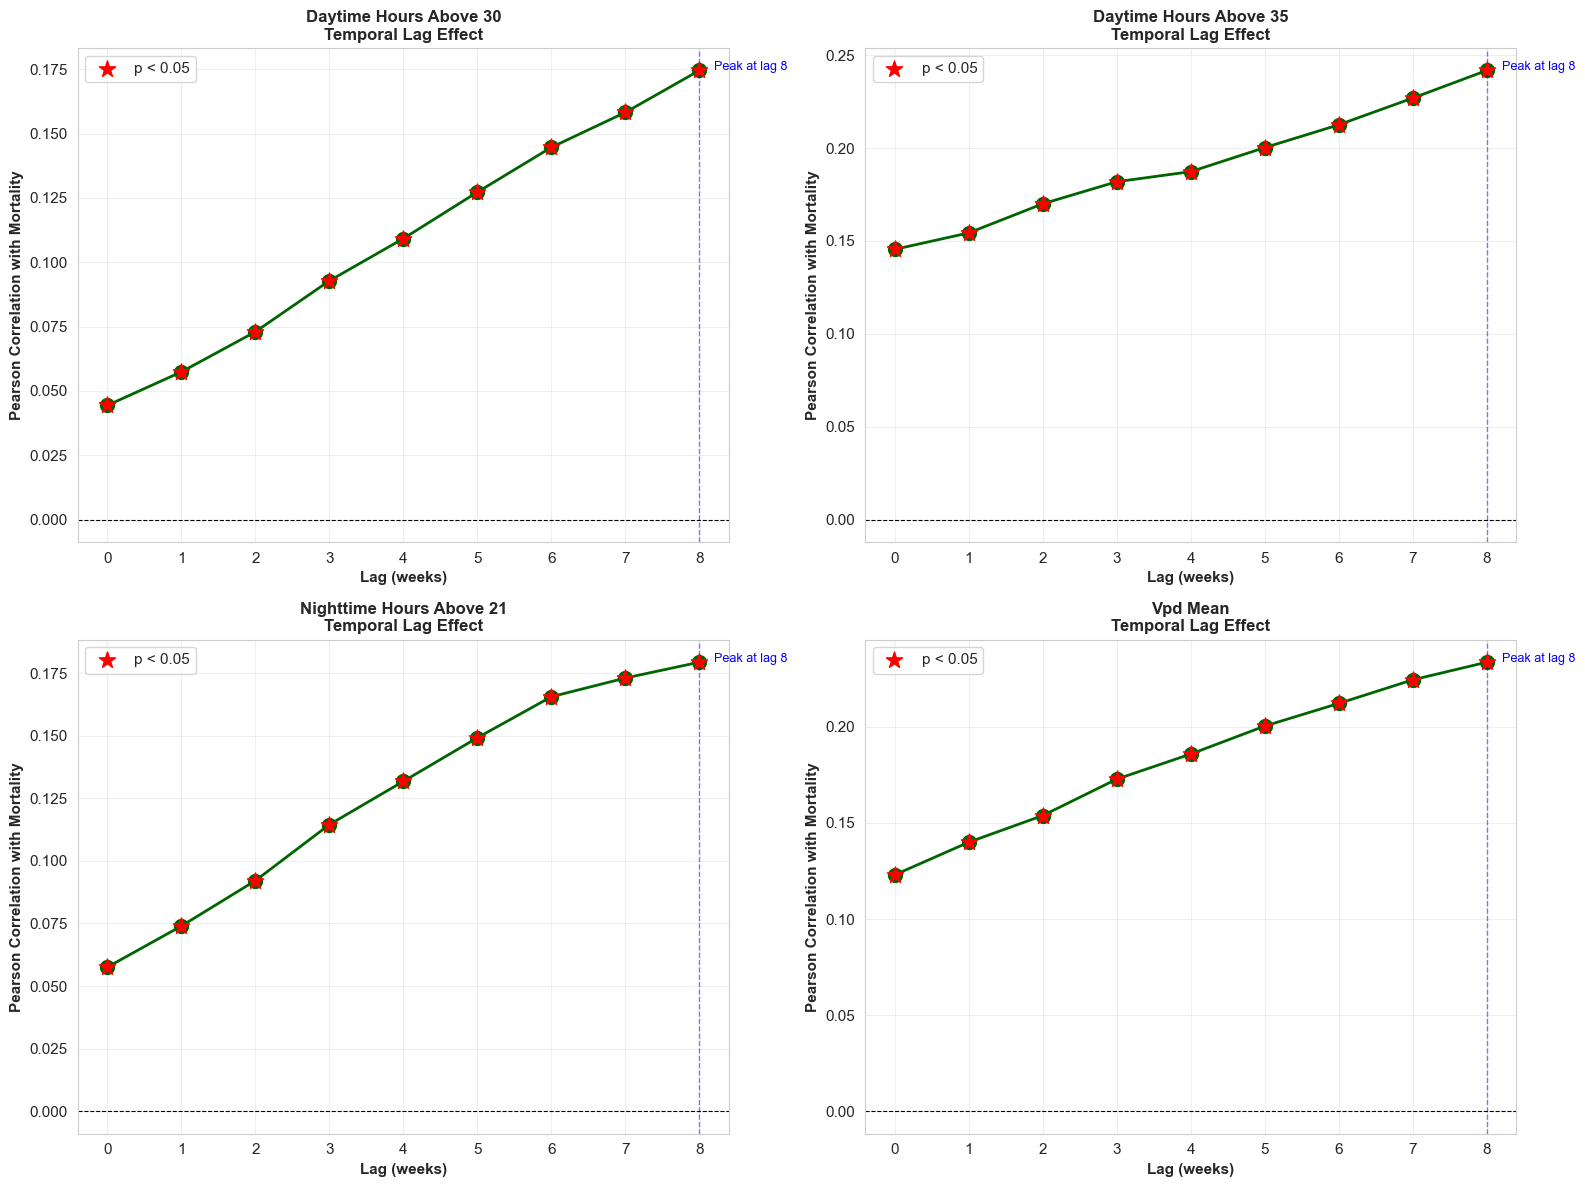

Figure saved: 03_temporal_lag_correlations.png


In [33]:
# Visualize lag correlations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(heat_metrics):
    ax = axes[idx]
    
    metric_lag_data = lag_corr_df[lag_corr_df['Metric'] == metric]
    
    # Plot correlation vs lag
    ax.plot(metric_lag_data['Lag'], metric_lag_data['Correlation'], 
            'o-', linewidth=2, markersize=10, color='darkgreen')
    
    # Mark significant correlations
    sig_data = metric_lag_data[metric_lag_data['P-value'] < 0.05]
    if len(sig_data) > 0:
        ax.scatter(sig_data['Lag'], sig_data['Correlation'], 
                  s=150, color='red', marker='*', zorder=5, label='p < 0.05')
    
    # Find peak correlation
    peak_idx = metric_lag_data['Correlation'].abs().idxmax()
    peak_lag = metric_lag_data.loc[peak_idx, 'Lag']
    peak_corr = metric_lag_data.loc[peak_idx, 'Correlation']
    
    ax.axvline(peak_lag, color='blue', linewidth=1, linestyle='--', alpha=0.5)
    ax.text(peak_lag + 0.2, peak_corr, f'Peak at lag {int(peak_lag)}', 
            fontsize=9, color='blue')
    
    ax.set_xlabel('Lag (weeks)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pearson Correlation with Mortality', fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.replace("mean_", "").replace("_", " ").title()}\nTemporal Lag Effect', 
                 fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if len(sig_data) > 0:
        ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(range(0, max_lag + 1))

plt.tight_layout()
plt.savefig('../../figures/cumulative_heat_recovery/03_temporal_lag_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 03_temporal_lag_correlations.png")

## 7. Acute vs Chronic Exposure Patterns

Compare the effects of rare extreme heat vs consistent moderate heat.

In [34]:
# Classify exposure patterns based on frequency and intensity
def classify_exposure_pattern(row):
    """
    Classify heat exposure pattern over 8-week window.
    
    Categories:
    - Low: Minimal heat exposure
    - Acute: High intensity, low frequency (rare extremes)
    - Chronic: Moderate intensity, high frequency (consistent moderate heat)
    - Severe: High intensity, high frequency
    """
    # Use 8-week cumulative data
    cum_moderate = row['mean_daytime_hours_above_30_cumulative_8wk']  # Total hours
    cum_extreme = row['mean_daytime_hours_above_35_cumulative_8wk']
    
    # Calculate weekly average over 8-week window
    avg_moderate = cum_moderate / 8
    avg_extreme = cum_extreme / 8
    
    # Current week intensity
    current_moderate = row['mean_daytime_hours_above_30']
    current_extreme = row['mean_daytime_hours_above_35']
    
    # Classification logic
    if avg_moderate < 10:  # Low average
        return 'Low exposure'
    elif current_extreme > 20 and avg_extreme < 5:  # Spike in current week, low average
        return 'Acute (rare extreme)'
    elif avg_moderate > 20 and current_extreme < 10:  # High average, low current extreme
        return 'Chronic (consistent moderate)'
    elif avg_moderate > 25 and avg_extreme > 10:  # High in both
        return 'Severe (chronic extreme)'
    else:
        return 'Moderate exposure'

cattle_focus['exposure_pattern'] = cattle_focus.apply(classify_exposure_pattern, axis=1)

print("Exposure Pattern Distribution:")
print(cattle_focus['exposure_pattern'].value_counts())
print(f"\nPercentage:")
print((cattle_focus['exposure_pattern'].value_counts(normalize=True) * 100).round(1))

Exposure Pattern Distribution:
exposure_pattern
Severe (chronic extreme)         2142
Chronic (consistent moderate)    1857
Low exposure                      383
Name: count, dtype: int64

Percentage:
exposure_pattern
Severe (chronic extreme)         48.9
Chronic (consistent moderate)    42.4
Low exposure                      8.7
Name: proportion, dtype: float64


In [35]:
# Compare mortality by exposure pattern
exposure_mortality = cattle_focus.groupby('exposure_pattern')[mortality_var].agg([
    'mean', 'median', 'std', 'count'
])

print("\nMortality by Exposure Pattern:")
print(exposure_mortality)

# Statistical test
from scipy.stats import kruskal

exposure_groups = []
for pattern in cattle_focus['exposure_pattern'].unique():
    pattern_data = cattle_focus[cattle_focus['exposure_pattern'] == pattern][mortality_var].dropna()
    if len(pattern_data) > 0:
        exposure_groups.append(pattern_data)

if len(exposure_groups) > 2:
    h_stat, p_value = kruskal(*exposure_groups)
    print(f"\nKruskal-Wallis H-test:")
    print(f"  H-statistic: {h_stat:.3f}")
    print(f"  P-value: {p_value:.4e}")
    print(f"  Interpretation: {'Significant' if p_value < 0.05 else 'Not significant'} differences across patterns")


Mortality by Exposure Pattern:
                                    mean  median       std  count
exposure_pattern                                                 
Chronic (consistent moderate)  15.895008   14.80  4.952088   1857
Low exposure                   14.345457   13.70  3.574924    383
Severe (chronic extreme)       16.822306   15.75  5.252353   2142

Kruskal-Wallis H-test:
  H-statistic: 82.265
  P-value: 1.3692e-18
  Interpretation: Significant differences across patterns


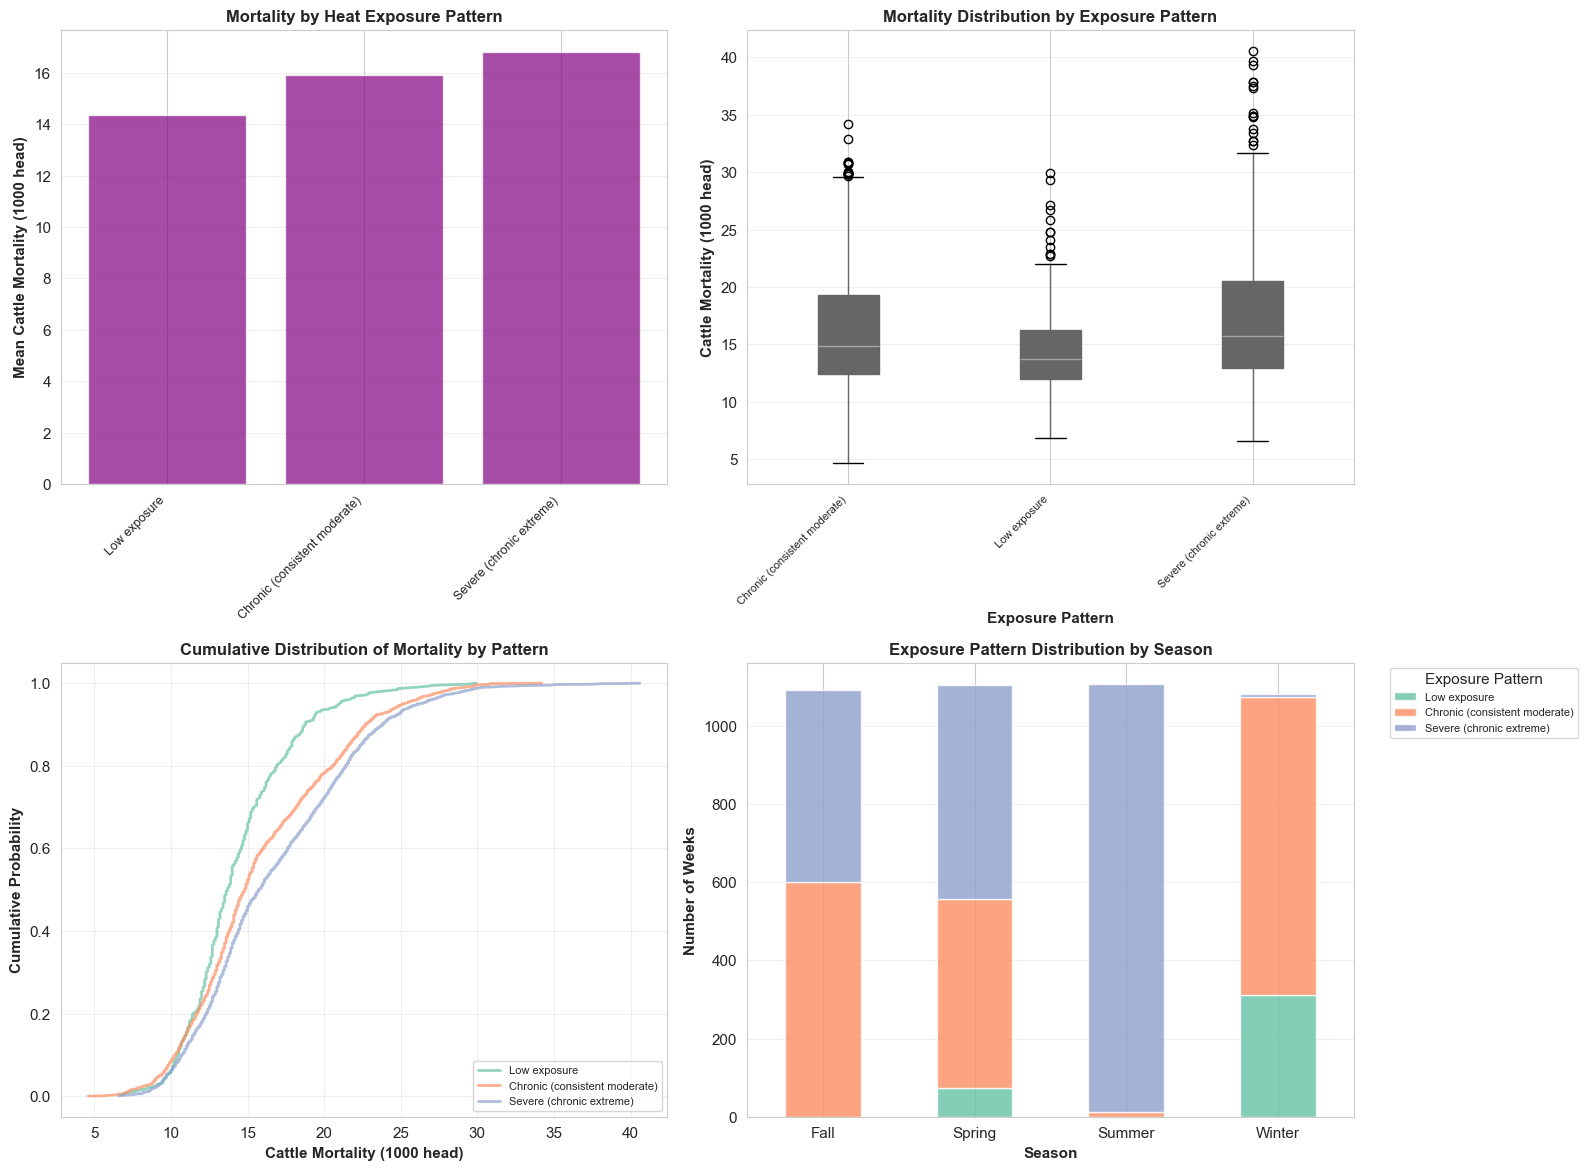

Figure saved: 04_acute_vs_chronic_exposure.png


In [36]:
# Visualize exposure patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mortality by exposure pattern
ax = axes[0, 0]
exposure_order = ['Low exposure', 'Moderate exposure', 'Chronic (consistent moderate)', 
                  'Acute (rare extreme)', 'Severe (chronic extreme)']
exposure_order = [e for e in exposure_order if e in cattle_focus['exposure_pattern'].unique()]

mortality_by_pattern = []
for pattern in exposure_order:
    pattern_data = cattle_focus[cattle_focus['exposure_pattern'] == pattern][mortality_var].dropna()
    if len(pattern_data) > 0:
        mortality_by_pattern.append(pattern_data.mean())
    else:
        mortality_by_pattern.append(np.nan)

ax.bar(range(len(exposure_order)), mortality_by_pattern, color='purple', alpha=0.7)
ax.set_xticks(range(len(exposure_order)))
ax.set_xticklabels(exposure_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_title('Mortality by Heat Exposure Pattern', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Box plot comparison
ax = axes[0, 1]
cattle_focus[cattle_focus['exposure_pattern'].isin(exposure_order)].boxplot(
    column=mortality_var, by='exposure_pattern', ax=ax, patch_artist=True
)
ax.set_xlabel('Exposure Pattern', fontsize=11, fontweight='bold')
ax.set_ylabel('Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_title('Mortality Distribution by Exposure Pattern', fontsize=12, fontweight='bold')
plt.suptitle('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Cumulative distribution function
ax = axes[1, 0]
for pattern in exposure_order:
    pattern_data = cattle_focus[cattle_focus['exposure_pattern'] == pattern][mortality_var].dropna().sort_values()
    if len(pattern_data) > 0:
        cdf = np.arange(1, len(pattern_data) + 1) / len(pattern_data)
        ax.plot(pattern_data, cdf, linewidth=2, label=pattern, alpha=0.7)

ax.set_xlabel('Cattle Mortality (1000 head)', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax.set_title('Cumulative Distribution of Mortality by Pattern', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

# Plot 4: Seasonal distribution of exposure patterns
ax = axes[1, 1]
pattern_by_season = cattle_focus.groupby(['season', 'exposure_pattern']).size().unstack(fill_value=0)
pattern_by_season = pattern_by_season[exposure_order] if all(e in pattern_by_season.columns for e in exposure_order) else pattern_by_season
pattern_by_season.plot(kind='bar', stacked=True, ax=ax, alpha=0.8)
ax.set_xlabel('Season', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Weeks', fontsize=11, fontweight='bold')
ax.set_title('Exposure Pattern Distribution by Season', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Exposure Pattern', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../figures/cumulative_heat_recovery/04_acute_vs_chronic_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 04_acute_vs_chronic_exposure.png")

## 8. Summary and Key Findings

In [37]:
print("="*80)
print("KEY FINDINGS: CUMULATIVE HEAT LOAD AND RECOVERY DYNAMICS")
print("="*80)

print("\n1. OPTIMAL CUMULATIVE WINDOW:")
for metric in heat_metrics:
    metric_corrs = corr_df[corr_df['Metric'] == metric]
    best_window = metric_corrs.loc[metric_corrs['Correlation'].abs().idxmax()]
    print(f"   {metric}:")
    print(f"     Best window: {best_window['Window']}")
    print(f"     Correlation: {best_window['Correlation']:.4f}")

print("\n2. HEAT WAVE EFFECTS:")
if len(hw_mortality) > 0 and len(normal_mortality) > 0:
    print(f"   Mean mortality during heat waves: {hw_mortality.mean():.1f}")
    print(f"   Mean mortality in normal periods: {normal_mortality.mean():.1f}")
    print(f"   Fold increase: {hw_mortality.mean() / normal_mortality.mean():.2f}x")
    print(f"   Statistical significance: p = {p_value:.4e}")
else:
    print("   Insufficient heat wave data for comparison")

print("\n3. RECOVERY PERIOD IMPORTANCE:")
short_recovery = cattle_focus[cattle_focus['recovery_category'] == 'Short recovery (1-2 wk)'][mortality_var].mean()
long_recovery = cattle_focus[cattle_focus['recovery_category'] == 'Extended recovery (>8 wk)'][mortality_var].mean()
if not np.isnan(short_recovery) and not np.isnan(long_recovery):
    print(f"   Short recovery (1-2 wk) mortality: {short_recovery:.1f}")
    print(f"   Extended recovery (>8 wk) mortality: {long_recovery:.1f}")
    print(f"   Difference: {short_recovery - long_recovery:.1f}")

print("\n4. TEMPORAL MEMORY:")
for metric in heat_metrics:
    metric_lag_data = lag_corr_df[lag_corr_df['Metric'] == metric]
    peak_lag = metric_lag_data.loc[metric_lag_data['Correlation'].abs().idxmax(), 'Lag']
    peak_corr = metric_lag_data.loc[metric_lag_data['Correlation'].abs().idxmax(), 'Correlation']
    print(f"   {metric}:")
    print(f"     Peak correlation at lag {int(peak_lag)} weeks (r = {peak_corr:.3f})")

print("\n5. ACUTE VS CHRONIC EXPOSURE:")
acute_mortality = cattle_focus[cattle_focus['exposure_pattern'] == 'Acute (rare extreme)'][mortality_var].mean()
chronic_mortality = cattle_focus[cattle_focus['exposure_pattern'] == 'Chronic (consistent moderate)'][mortality_var].mean()
if not np.isnan(acute_mortality) and not np.isnan(chronic_mortality):
    print(f"   Acute (rare extreme) mortality: {acute_mortality:.1f}")
    print(f"   Chronic (consistent moderate) mortality: {chronic_mortality:.1f}")
    if chronic_mortality > acute_mortality:
        print(f"   Chronic exposure causes {chronic_mortality - acute_mortality:.1f} more deaths per week")
    else:
        print(f"   Acute exposure causes {acute_mortality - chronic_mortality:.1f} more deaths per week")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print("")
print("1. Cumulative heat load over 4-6 weeks predicts mortality better than single-week exposure")
print("2. Heat waves significantly increase mortality compared to normal periods")
print("3. Short recovery periods between heat events elevate mortality risk")
print("4. Heat exposure shows temporal memory effects lasting several weeks")
print("5. Chronic moderate heat may be as dangerous as rare acute extremes")
print("")
print("Recommendation: Monitor cumulative heat load and ensure adequate recovery periods")
print("="*80)

KEY FINDINGS: CUMULATIVE HEAT LOAD AND RECOVERY DYNAMICS

1. OPTIMAL CUMULATIVE WINDOW:
   mean_daytime_hours_above_30:
     Best window: 8 weeks
     Correlation: 0.1107
   mean_daytime_hours_above_35:
     Best window: 8 weeks
     Correlation: 0.2273
   mean_nighttime_hours_above_21:
     Best window: 8 weeks
     Correlation: 0.1247
   mean_vpd_mean:
     Best window: 8 weeks
     Correlation: 0.1881

2. HEAT WAVE EFFECTS:
   Mean mortality during heat waves: 16.6
   Mean mortality in normal periods: 15.4
   Fold increase: 1.08x
   Statistical significance: p = 1.3692e-18

3. RECOVERY PERIOD IMPORTANCE:
   Short recovery (1-2 wk) mortality: 16.2
   Extended recovery (>8 wk) mortality: 14.1
   Difference: 2.1

4. TEMPORAL MEMORY:
   mean_daytime_hours_above_30:
     Peak correlation at lag 8 weeks (r = 0.175)
   mean_daytime_hours_above_35:
     Peak correlation at lag 8 weeks (r = 0.242)
   mean_nighttime_hours_above_21:
     Peak correlation at lag 8 weeks (r = 0.179)
   mean_vpd_

## 9. Export Results

In [38]:
# Save processed data with cumulative metrics
from pathlib import Path

output_cols = ['week_ending', 'region', 'year', 'month', 'season', mortality_var]

# Add cumulative metrics
for window in window_sizes:
    for metric in heat_metrics:
        output_cols.append(f'{metric}_cumulative_{window}wk')

# Add heat wave and recovery variables
output_cols.extend(['heat_wave_id', 'in_heat_wave', 'weeks_since_heat', 
                    'recovery_category', 'exposure_pattern'])

output_data = cattle_focus[output_cols].copy()

# Use pathlib and config paths - cattle data is in data/cattle_data/
from config import PROJECT_ROOT
output_dir = PROJECT_ROOT / 'data' / 'cattle_data'
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / 'cattle_cumulative_recovery_data.csv'
output_data.to_csv(output_file, index=False)
print(f"\nData saved to: {output_file}")
print(f"Shape: {output_data.shape}")

# Save heat wave characteristics
if len(hw_df) > 0:
    hw_file = output_dir / 'heat_wave_characteristics.csv'
    hw_df.to_csv(hw_file, index=False)
    print(f"\nHeat wave data saved to: {hw_file}")

print("\n✓ Analysis complete! All figures saved to figures/cumulative_heat_recovery/")


Data saved to: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/notebooks/03_analysis/../../data/cattle_data/cattle_cumulative_recovery_data.csv
Shape: (4382, 27)

Heat wave data saved to: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/notebooks/03_analysis/../../data/cattle_data/heat_wave_characteristics.csv

✓ Analysis complete! All figures saved to figures/cumulative_heat_recovery/
